# Bagian C — Probabilitas dan Statistik dengan Python

**Fundamen Sains Data: Pengantar Python untuk Sains Data, Probabilitas, dan Statistika**
Program Studi Informatika, Program Sarjana, Universitas Islam Indonesia

Bagian ini memakai Python untuk dua pekerjaan yang saling melengkapi. **Statistik deskriptif**
meringkas data yang sudah diamati, misalnya nilai ujian satu kelas. **Probabilitas** mengukur
seberapa mungkin suatu kejadian terjadi, baik melalui simulasi maupun melalui model distribusi.
Keduanya bertemu pada studi kasus di akhir bagian.

---
## C.0 Persiapan: impor library dan dataset

Cell pertama mengimpor semua library yang diperlukan, termasuk SciPy, library fungsi ilmiah yang
menyediakan distribusi probabilitas. Dua distribusi yang diimpor adalah `binom` (binomial) dan
`norm` (normal).

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

print("Library siap digunakan")

Library siap digunakan


Dataset utama adalah nilai ujian 20 mahasiswa yang ditulis langsung di notebook dan dipakai di
seluruh subbagian C.1.

In [2]:
# Nilai ujian 20 mahasiswa (data pengamatan)
nilai_ujian = np.array([55, 60, 62, 65, 68, 70, 70, 72, 75, 76,
                        78, 80, 82, 82, 85, 88, 90, 92, 95, 98])

# Versi pandas Series dari data yang sama
nilai_series = pd.Series(nilai_ujian, name="nilai_ujian")

print(nilai_ujian)

[55 60 62 65 68 70 70 72 75 76 78 80 82 82 85 88 90 92 95 98]


```text
[55 60 62 65 68 70 70 72 75 76 78 80 82 82 85 88 90 92 95 98]
```

---
## C.1 Statistik deskriptif

Statistik deskriptif adalah ukuran ringkas yang menggambarkan sekumpulan data: di mana pusatnya,
seberapa menyebar, dan bagaimana bentuk sebarannya.

### C.1.1 Jumlah data, mean, median, dan modus

Tiga ukuran pemusatan data (*measures of central tendency*) yang paling umum adalah:

- **Mean (rata-rata):** jumlah semua nilai dibagi banyaknya data.
- **Median:** nilai tengah setelah data diurutkan. Bila banyaknya data genap, median adalah
  rata-rata dua nilai tengah. Median tidak mudah terpengaruh nilai ekstrem.
- **Modus (mode):** nilai yang paling sering muncul. Sebuah data dapat memiliki lebih dari satu
  modus.

Rumus mean untuk data berukuran $n$ adalah:

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \qquad (1)$$

Keterangan: $\bar{x}$ = mean (rata-rata) data; $n$ = banyaknya data; $x_i$ = nilai data ke-$i$;
$i$ = indeks data, dari 1 sampai $n$; $\sum$ = penjumlahan semua suku dari $i=1$ sampai $i=n$.

**Perhitungan manual.** Untuk lima nilai kuis 70, 80, 75, 90, dan 85, banyaknya data $n=5$ dan
jumlahnya $70+80+75+90+85=400$. Dengan demikian, $\bar{x}=400/5=80$. Setelah diurutkan
(70, 75, 80, 85, 90), nilai tengahnya adalah 80, sehingga median juga 80. Hasil ini dapat dicek
dengan Python:

In [3]:
kuis = np.array([70, 80, 75, 90, 85])
print("Mean   :", np.mean(kuis))
print("Median :", np.median(kuis))

Mean   : 80.0
Median : 80.0


```text
Mean   : 80.0
Median : 80.0
```

**Contoh kasus.** Berapa banyaknya data, mean, median, dan modus nilai ujian 20 mahasiswa?

In [4]:
n = len(nilai_ujian)
mean_nilai = np.mean(nilai_ujian)
median_nilai = np.median(nilai_ujian)
modus_nilai = nilai_series.mode()   # semua modus, bisa lebih dari satu

print(f"Jumlah data : {n}")
print(f"Mean        : {mean_nilai:.2f}")
print(f"Median      : {median_nilai:.2f}")
print(f"Modus       : {modus_nilai.tolist()}")

# Frekuensi setiap nilai untuk memeriksa modus
print(nilai_series.value_counts().head(4))

Jumlah data : 20
Mean        : 77.15
Median      : 77.00
Modus       : [70, 82]
nilai_ujian
70    2
82    2
55    1
60    1
Name: count, dtype: int64


**Hasil yang diharapkan.**

```text
Jumlah data : 20
Mean        : 77.15
Median      : 77.00
Modus       : [70, 82]
nilai_ujian
70    2
82    2
55    1
60    1
Name: count, dtype: int64
```

**Interpretasi.** Rata-rata nilai kelas adalah 77.15 dan median 77.00. Kedua angka hampir sama,
menandakan sebaran yang cukup seimbang. Data ini **bimodal** karena memiliki dua modus, 70 dan 82,
masing-masing muncul dua kali. Pada data sekecil ini, modus kurang informatif.

Metode `mode()` milik pandas dipilih karena mengembalikan semua modus, sedangkan `scipy.stats.mode()`
hanya mengembalikan satu modus (yang terkecil).

### C.1.2 Minimum, maksimum, dan rentang

Minimum dan maksimum adalah nilai terkecil dan terbesar. Rentang (*range*) adalah selisih keduanya
dan merupakan ukuran penyebaran yang paling sederhana:

$$R = x_{maks} - x_{min} \qquad (2)$$

Keterangan: $R$ = rentang data; $x_{maks}$ = nilai terbesar; $x_{min}$ = nilai terkecil.

**Contoh kasus.** Berapa nilai terendah, tertinggi, dan rentang nilai ujian?

In [5]:
nilai_min = np.min(nilai_ujian)
nilai_max = np.max(nilai_ujian)
rentang = nilai_max - nilai_min

print(f"Minimum : {nilai_min}")
print(f"Maksimum: {nilai_max}")
print(f"Rentang : {rentang}")

Minimum : 55
Maksimum: 98
Rentang : 43


**Hasil yang diharapkan.**

```text
Minimum : 55
Maksimum: 98
Rentang : 43
```

**Interpretasi.** Nilai mahasiswa tersebar dari 55 sampai 98, dengan rentang 43 poin. Rentang hanya
memakai dua nilai paling ekstrem, sehingga mudah berubah drastis karena satu nilai yang tidak biasa.
Ukuran penyebaran yang memakai seluruh data dibahas berikutnya.

### C.1.3 Varians dan standar deviasi

Varians mengukur rata-rata kuadrat jarak setiap data terhadap mean. Standar deviasi adalah akar
kuadrat varians, sehingga satuannya sama dengan satuan data (dalam contoh ini: poin nilai). Semakin
besar standar deviasi, semakin menyebar data dari rata-ratanya.

Varians **populasi** dihitung dengan:

$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2 \qquad (3)$$

Varians **sampel** memakai pembagi $n-1$:

$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2 \qquad (4)$$

Standar deviasi adalah akar kuadrat dari varians:

$$s = \sqrt{s^2} \qquad (5)$$

Pembagi $n-1$ pada sampel dipakai karena mean sampel $\bar{x}$ dihitung dari data yang sama,
sehingga jarak data ke $\bar{x}$ cenderung sedikit lebih kecil daripada jarak ke mean populasi yang
sebenarnya. Pembagi yang lebih kecil mengoreksi kecenderungan tersebut.

**Perhitungan manual.** Gunakan kembali lima nilai kuis dengan $\bar{x}=80$. Simpangan setiap data
terhadap mean adalah $-10, 0, -5, 10, 5$, dan kuadratnya $100, 0, 25, 100, 25$ dengan jumlah 250.
Bila dianggap populasi, $\sigma^2 = 250/5 = 50$ dan $\sigma \approx 7{,}07$. Bila dianggap sampel,
$s^2 = 250/4 = 62{,}5$ dan $s \approx 7{,}91$.

NumPy dan pandas memiliki nilai bawaan yang berbeda, dan perbedaan ini sering menimbulkan kebingungan:

- `np.var()` dan `np.std()` memakai `ddof=0` (populasi) secara bawaan. Parameter `ddof` (*delta
  degrees of freedom*) menentukan pembagi $n-\text{ddof}$, sehingga `ddof=1` menghasilkan rumus sampel.
- `pandas.Series.var()` dan `pandas.Series.std()` memakai `ddof=1` (sampel) secara bawaan.

**Contoh kasus.** Nilai ujian 20 mahasiswa diperlakukan sebagai sampel dari seluruh mahasiswa yang
pernah atau akan mengikuti mata kuliah tersebut. Hitung varians dan standar deviasinya, lalu
bandingkan hasil NumPy dan pandas.

In [6]:
# Rumus sampel (ddof=1), dipakai di sisa modul
var_sampel = np.var(nilai_ujian, ddof=1)
std_sampel = np.std(nilai_ujian, ddof=1)
print(f"Varians sampel (NumPy, ddof=1)   : {var_sampel:.2f}")
print(f"Std sampel     (NumPy, ddof=1)   : {std_sampel:.2f}")
print(f"Std sampel     (pandas, bawaan)  : {nilai_series.std():.2f}")

# Sebagai pembanding: rumus populasi
print(f"Std populasi   (NumPy, bawaan)   : {np.std(nilai_ujian):.2f}")

Varians sampel (NumPy, ddof=1)   : 144.98
Std sampel     (NumPy, ddof=1)   : 12.04
Std sampel     (pandas, bawaan)  : 12.04
Std populasi   (NumPy, bawaan)   : 11.74


**Hasil yang diharapkan.**

```text
Varians sampel (NumPy, ddof=1)   : 144.98
Std sampel     (NumPy, ddof=1)   : 12.04
Std sampel     (pandas, bawaan)  : 12.04
Std populasi   (NumPy, bawaan)   : 11.74
```

**Interpretasi.** Standar deviasi sampel sebesar 12.04 berarti nilai mahasiswa umumnya berjarak
sekitar 12 poin dari rata-rata 77.15. NumPy dengan `ddof=1` dan pandas bawaan memberi hasil yang
sama, sedangkan rumus populasi memberi angka sedikit lebih kecil (11.74). Di sisa modul, standar
deviasi data pengamatan selalu memakai rumus sampel. Biasakan menuliskan `ddof` secara eksplisit
saat memakai NumPy.

### C.1.4 Kuartil, persentil, dan IQR

**Persentil ke-$p$** adalah nilai yang membatasi $p$ persen data terbawah. Kuartil adalah tiga
persentil khusus yang membagi data terurut menjadi empat bagian sama besar:

- $Q_1$ (kuartil pertama) = persentil ke-25.
- $Q_2$ (kuartil kedua) = persentil ke-50 = median.
- $Q_3$ (kuartil ketiga) = persentil ke-75.

**Interquartile range (IQR, jangkauan antarkuartil)** adalah lebar 50% data bagian tengah:

$$\text{IQR} = Q_3 - Q_1 \qquad (6)$$

IQR juga dipakai untuk menandai **pencilan** (*outlier*), yaitu data yang jauh dari kelompok utama.
Batas yang umum dipakai adalah:

$$B_{bawah} = Q_1 - 1{,}5 \times \text{IQR}, \qquad B_{atas} = Q_3 + 1{,}5 \times \text{IQR} \qquad (7)$$

Ada beberapa metode menghitung kuartil, sehingga hasil hitungan tangan di buku teks bisa sedikit
berbeda dari Python. NumPy dan pandas sama-sama memakai interpolasi linear secara bawaan.

**Contoh kasus.** Tentukan $Q_1$, median, $Q_3$, persentil ke-90, IQR, dan batas pencilan nilai ujian.

In [7]:
q1, q2, q3 = np.percentile(nilai_ujian, [25, 50, 75])
p90 = np.percentile(nilai_ujian, 90)
iqr = q3 - q1
batas_bawah = q1 - 1.5 * iqr
batas_atas = q3 + 1.5 * iqr

print(f"Q1 (persentil 25) : {q1:.2f}")
print(f"Q2 (median)       : {q2:.2f}")
print(f"Q3 (persentil 75) : {q3:.2f}")
print(f"Persentil 90      : {p90:.2f}")
print(f"IQR               : {iqr:.2f}")
print(f"Batas pencilan    : {batas_bawah:.2f} sampai {batas_atas:.2f}")

pencilan = nilai_ujian[(nilai_ujian < batas_bawah) | (nilai_ujian > batas_atas)]
print("Pencilan          :", pencilan)

# Ringkasan sekaligus dengan pandas
print(nilai_series.describe())

Q1 (persentil 25) : 69.50
Q2 (median)       : 77.00
Q3 (persentil 75) : 85.75
Persentil 90      : 92.30
IQR               : 16.25
Batas pencilan    : 45.12 sampai 110.12
Pencilan          : []
count    20.000000
mean     77.150000
std      12.040611
min      55.000000
25%      69.500000
50%      77.000000
75%      85.750000
max      98.000000
Name: nilai_ujian, dtype: float64


**Hasil yang diharapkan.**

```text
Q1 (persentil 25) : 69.50
Q2 (median)       : 77.00
Q3 (persentil 75) : 85.75
Persentil 90      : 92.30
IQR               : 16.25
Batas pencilan    : 45.12 sampai 110.12
Pencilan          : []
count    20.000000
mean     77.150000
std      12.040611
min      55.000000
25%      69.500000
50%      77.000000
75%      85.750000
max      98.000000
Name: nilai_ujian, dtype: float64
```

**Interpretasi.** Seperempat mahasiswa memperoleh nilai di bawah 69.5, dan seperempat lainnya di atas
85.75. Separuh mahasiswa di bagian tengah memiliki nilai dalam rentang 16.25 poin (IQR). Mahasiswa
dengan nilai di atas 92.3 termasuk 10% teratas kelas. Tidak ada pencilan, karena semua nilai berada di
antara batas 45.12 dan 110.12. Fungsi `describe()` merangkum seluruh ukuran tersebut dalam satu
perintah. Simbol `|` pada filter berarti "atau" untuk array.

### C.1.5 Histogram dan boxplot

Angka ringkasan perlu dilengkapi grafik agar bentuk sebaran data terlihat. Dua grafik yang paling
sering dipakai adalah:

- **Histogram** membagi rentang nilai menjadi beberapa interval (*bin*) dan menggambar batang
  setinggi banyaknya data di setiap interval. Histogram memperlihatkan bentuk sebaran: simetris,
  miring (*skewed*), atau memiliki beberapa puncak.
- **Boxplot** menggambar kotak dari $Q_1$ sampai $Q_3$ dengan garis median di dalamnya. Garis di
  kedua sisi kotak (*whisker*) menjangkau data terjauh yang masih berada di dalam batas pencilan
  rumus (7). Pencilan, bila ada, digambar sebagai titik terpisah.

**Contoh kasus.** Bagaimana bentuk sebaran nilai ujian, dan apakah ada nilai yang tidak wajar?

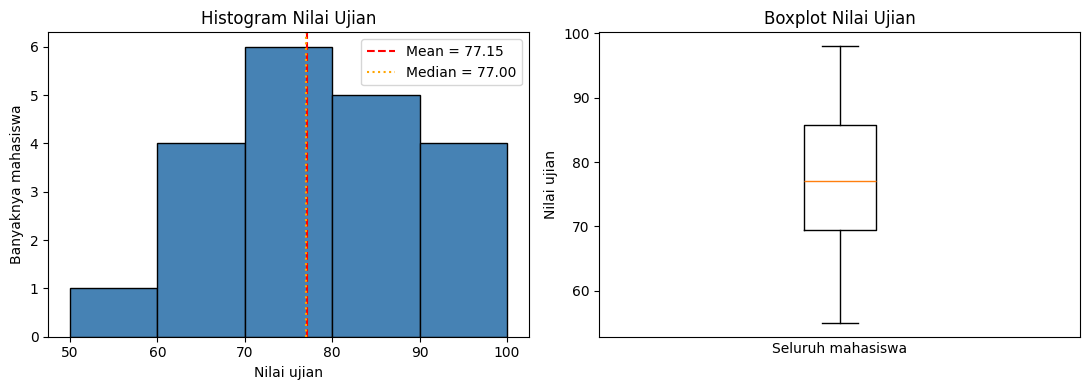

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram dengan garis mean dan median
axes[0].hist(nilai_ujian, bins=[50, 60, 70, 80, 90, 100],
             color="steelblue", edgecolor="black")
axes[0].axvline(mean_nilai, color="red", linestyle="--",
                label=f"Mean = {mean_nilai:.2f}")
axes[0].axvline(median_nilai, color="orange", linestyle=":",
                label=f"Median = {median_nilai:.2f}")
axes[0].set_title("Histogram Nilai Ujian")
axes[0].set_xlabel("Nilai ujian")
axes[0].set_ylabel("Banyaknya mahasiswa")
axes[0].legend()

# Boxplot (vertikal)
axes[1].boxplot(nilai_ujian)
axes[1].set_title("Boxplot Nilai Ujian")
axes[1].set_xlabel("Seluruh mahasiswa")
axes[1].set_ylabel("Nilai ujian")
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

**Hasil yang diharapkan.** Dua grafik berdampingan seperti pada **Gambar 9** modul. Histogram
memiliki lima batang untuk interval 50–60, 60–70, 70–80, 80–90, dan 90–100, dengan tinggi berturut-turut
1, 4, 6, 5, dan 4. Dua garis putus-putus vertikal untuk mean dan median hampir berimpit di sekitar nilai
77. Boxplot tegak menampilkan kotak dari 69.5 sampai 85.75 pada sumbu vertikal, garis median di 77, dan
whisker dari 55 sampai 98 tanpa titik pencilan.

**Interpretasi.** Pada histogram, sumbu horizontal adalah nilai ujian dan sumbu vertikal adalah
banyaknya mahasiswa per interval. Interval 70 sampai 80 memiliki mahasiswa terbanyak, dan mean yang
hampir berimpit dengan median menandakan sebaran cukup simetris. Pada boxplot, kotak memuat separuh
mahasiswa di bagian tengah, dan ketiadaan titik di luar whisker sejalan dengan hasil perhitungan
pencilan di C.1.4.

---
## C.2 Probabilitas melalui simulasi

### C.2.1 Ruang sampel, kejadian, dan probabilitas teoretis

**Percobaan acak** adalah proses yang hasilnya tidak dapat dipastikan sebelumnya, misalnya melempar
dadu. **Ruang sampel** $S$ adalah himpunan semua hasil yang mungkin. Untuk satu dadu,
$S = \{1,2,3,4,5,6\}$. **Kejadian** $A$ adalah bagian dari ruang sampel yang diperhatikan, misalnya
"muncul angka genap", $A = \{2,4,6\}$.

Bila setiap hasil memiliki peluang yang sama, probabilitas kejadian dihitung dengan:

$$P(A) = \frac{|A|}{|S|} \qquad (8)$$

Keterangan: $P(A)$ = probabilitas kejadian $A$, bernilai antara 0 (mustahil) dan 1 (pasti);
$|A|$ = banyaknya hasil yang termasuk kejadian $A$; $|S|$ = banyaknya seluruh hasil dalam ruang sampel.

**Perhitungan manual.** Untuk dadu adil, $P(\text{genap}) = 3/6 = 0{,}5$ dan
$P(\text{angka} > 4) = |\{5,6\}|/6 = 2/6 \approx 0{,}3333$.

In [9]:
ruang_sampel = [1, 2, 3, 4, 5, 6]
kejadian_genap = [x for x in ruang_sampel if x % 2 == 0]
kejadian_lebih_4 = [x for x in ruang_sampel if x > 4]

p_genap = len(kejadian_genap) / len(ruang_sampel)
p_lebih_4 = len(kejadian_lebih_4) / len(ruang_sampel)

print("Kejadian genap :", kejadian_genap, "-> P =", round(p_genap, 4))
print("Kejadian > 4   :", kejadian_lebih_4, "-> P =", round(p_lebih_4, 4))

Kejadian genap : [2, 4, 6] -> P = 0.5
Kejadian > 4   : [5, 6] -> P = 0.3333


```text
Kejadian genap : [2, 4, 6] -> P = 0.5
Kejadian > 4   : [5, 6] -> P = 0.3333
```

### C.2.2 Frekuensi relatif dari simulasi

Probabilitas teoretis dapat diperiksa dengan simulasi: melakukan percobaan berkali-kali dengan
komputer, lalu menghitung **frekuensi relatif**, yaitu proporsi percobaan yang menghasilkan kejadian
tersebut:

$$\hat{P}(A) = \frac{n_A}{n} \qquad (9)$$

Keterangan: $\hat{P}(A)$ = frekuensi relatif kejadian $A$, sebagai taksiran probabilitas dari simulasi;
$n_A$ = banyaknya percobaan yang menghasilkan kejadian $A$; $n$ = banyaknya seluruh percobaan.

Bilangan acak di komputer dihasilkan oleh *random number generator* (RNG). RNG yang diberi **seed**
(bilangan awal) yang sama akan menghasilkan deret bilangan acak yang sama, sehingga hasil simulasi dapat
diulang (*reproducible*). Modul ini memakai `np.random.default_rng(42)`. Generator dibuat ulang di setiap
cell simulasi agar hasil cell tersebut tetap sama walaupun cell lain dijalankan lebih dulu.

**Contoh kasus.** Lempar dadu sebanyak 10, 100, 1.000, 10.000, dan 100.000 kali. Bandingkan frekuensi
relatif angka genap dengan probabilitas teoretis 0.5.

In [10]:
rng = np.random.default_rng(42)

for banyak_lemparan in [10, 100, 1_000, 10_000, 100_000]:
    lemparan = rng.integers(1, 7, size=banyak_lemparan)   # angka 1 sampai 6
    frek_relatif = np.mean(lemparan % 2 == 0)              # proporsi genap
    selisih = abs(frek_relatif - p_genap)
    print(f"n = {banyak_lemparan:>7}: frekuensi relatif = {frek_relatif:.4f}, "
          f"selisih dengan teori = {selisih:.4f}")

n =      10: frekuensi relatif = 0.3000, selisih dengan teori = 0.2000
n =     100: frekuensi relatif = 0.3700, selisih dengan teori = 0.1300
n =    1000: frekuensi relatif = 0.4930, selisih dengan teori = 0.0070
n =   10000: frekuensi relatif = 0.5053, selisih dengan teori = 0.0053
n =  100000: frekuensi relatif = 0.4994, selisih dengan teori = 0.0006


**Hasil yang diharapkan** (ilustrasi dengan seed 42; angka dapat berbeda bila seed atau versi NumPy
berbeda):

```text
n =      10: frekuensi relatif = 0.3000, selisih dengan teori = 0.2000
n =     100: frekuensi relatif = 0.3700, selisih dengan teori = 0.1300
n =    1000: frekuensi relatif = 0.4930, selisih dengan teori = 0.0070
n =   10000: frekuensi relatif = 0.5053, selisih dengan teori = 0.0053
n =  100000: frekuensi relatif = 0.4994, selisih dengan teori = 0.0006
```

**Interpretasi.** `rng.integers(1, 7, size=n)` menghasilkan $n$ bilangan bulat dari 1 sampai 6, dan
`np.mean()` dari array boolean sama dengan proporsi nilai `True`. Dengan 10 lemparan, frekuensi relatif
angka genap hanya 0.3, jauh dari 0.5. Dengan 100 lemparan masih 0.37. Mulai 1.000 lemparan, frekuensi
relatif sudah berada di sekitar 0.5, dan pada 100.000 lemparan selisihnya tinggal 0.0006. Pada percobaan
sedikit, hasil sangat dipengaruhi kebetulan. Di sini selisihnya kebetulan selalu mengecil, tetapi pola
itu tidak dijamin, seperti terlihat pada grafik berikutnya.

### C.2.3 Frekuensi relatif seiring bertambahnya percobaan

Hasil simulasi dadu hanya menampilkan lima titik. Grafik berikut menampilkan frekuensi relatif setelah
setiap lemparan koin, sehingga perjalanan nilainya terlihat utuh.

**Contoh kasus.** Lempar koin adil sebanyak 2.000 kali. Bagaimana frekuensi relatif sisi kepala berubah
dari lemparan pertama sampai terakhir?

Setelah 10 lemparan   : 0.4000
Setelah 100 lemparan  : 0.5200
Setelah 2000 lemparan : 0.5010


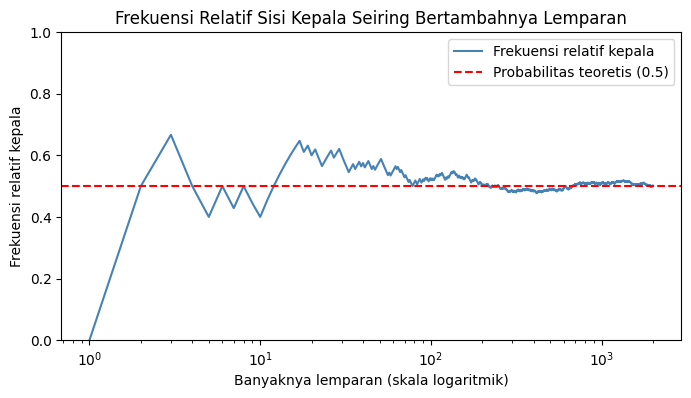

In [11]:
rng = np.random.default_rng(42)

banyak_lemparan = 2_000
koin = rng.integers(0, 2, size=banyak_lemparan)        # 1 = kepala, 0 = ekor
nomor_lemparan = np.arange(1, banyak_lemparan + 1)
frek_kumulatif = np.cumsum(koin) / nomor_lemparan       # proporsi kepala sejauh ini

print(f"Setelah 10 lemparan   : {frek_kumulatif[9]:.4f}")
print(f"Setelah 100 lemparan  : {frek_kumulatif[99]:.4f}")
print(f"Setelah 2000 lemparan : {frek_kumulatif[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(nomor_lemparan, frek_kumulatif, color="steelblue",
         label="Frekuensi relatif kepala")
plt.axhline(0.5, color="red", linestyle="--", label="Probabilitas teoretis (0.5)")
plt.xscale("log")
plt.title("Frekuensi Relatif Sisi Kepala Seiring Bertambahnya Lemparan")
plt.xlabel("Banyaknya lemparan (skala logaritmik)")
plt.ylabel("Frekuensi relatif kepala")
plt.ylim(0, 1)
plt.legend()
plt.show()

**Hasil yang diharapkan** (ilustrasi dengan seed 42):

```text
Setelah 10 lemparan   : 0.4000
Setelah 100 lemparan  : 0.5200
Setelah 2000 lemparan : 0.5010
```

Grafiknya (**Gambar 10**) berupa satu garis biru dan satu garis putus-putus merah horizontal di 0.5.
Sumbu horizontal memakai skala logaritmik agar lemparan awal (1 sampai 100) tidak terlihat berimpitan.

**Interpretasi.** Garis biru bergejolak tajam pada puluhan lemparan pertama, lalu bergerak di sekitar 0.5
setelah ratusan lemparan. Garis tidak turun lurus: setelah 200 lemparan nilainya 0.505, lalu menjauh
menjadi sekitar 0.483 setelah 300 lemparan, sebelum kembali ke 0.501 setelah 2.000 lemparan. Pola ini
dikenal sebagai **hukum bilangan besar** (*law of large numbers*): dengan jumlah percobaan yang terus
bertambah, frekuensi relatif cenderung mendekati probabilitas teoretis. Hukum ini menggambarkan
kecenderungan jangka panjang, bukan jaminan bahwa selisihnya mengecil pada setiap penambahan percobaan,
dan simulasi tidak akan memberi nilai teoretis secara persis.

---
## C.3 Variabel acak diskrit

### C.3.1 Variabel acak dan distribusi Bernoulli

**Variabel acak** (*random variable*) adalah aturan yang memberi angka pada setiap hasil percobaan acak.
Variabel acak biasanya ditulis dengan huruf kapital, misalnya $X$, sedangkan nilai tertentunya ditulis
dengan huruf kecil, misalnya $x$. Contohnya, bila sebuah koin dilempar tiga kali, $X$ = "banyaknya sisi
kepala" dapat bernilai 0, 1, 2, atau 3.

Variabel acak disebut **diskrit** bila nilainya dapat dihitung satu per satu (0, 1, 2, ...). Probabilitas
setiap nilai diberikan oleh *probability mass function* (PMF, fungsi massa probabilitas), yaitu $P(X=x)$.

Distribusi diskrit paling sederhana adalah **Bernoulli**, yaitu satu percobaan dengan dua kemungkinan
hasil: berhasil (diberi nilai 1) dengan probabilitas $p$ atau gagal (diberi nilai 0) dengan probabilitas
$1-p$. Contohnya satu lemparan koin, dengan "kepala" sebagai keberhasilan. PMF-nya:

$$P(X=x) = p^x (1-p)^{1-x}, \qquad x \in \{0, 1\} \qquad (10)$$

Untuk $x=1$, rumus menghasilkan $p$, dan untuk $x=0$ menghasilkan $1-p$. Istilah "berhasil" tidak harus
berarti hal yang baik; istilah ini hanya menandai hasil yang sedang dihitung.

### C.3.2 Distribusi binomial dan PMF

Distribusi **binomial** menghitung banyaknya keberhasilan dari $n$ percobaan Bernoulli yang saling bebas
(hasil satu percobaan tidak memengaruhi yang lain) dengan probabilitas berhasil $p$ yang sama di setiap
percobaan. PMF-nya:

$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k} \qquad (11)$$

Keterangan: $X$ = banyaknya keberhasilan; $k = 0,1,\dots,n$; $n$ = banyaknya percobaan; $p$ = probabilitas
berhasil pada setiap percobaan; $\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$ = banyaknya cara memilih $k$
keberhasilan dari $n$ percobaan.

**Perhitungan manual.** Sebuah koin adil ($p=0{,}5$) dilempar 3 kali. Berapa probabilitas tepat 2 kepala?
Urutan yang menghasilkan 2 kepala ada tiga: KKE, KEK, dan EKK, sehingga $\binom{3}{2}=3$. Setiap urutan
memiliki probabilitas $0{,}5^2 \times 0{,}5^1 = 0{,}125$. Jadi, $P(X=2) = 3 \times 0{,}125 = 0{,}375$.

In [12]:
# Memeriksa perhitungan manual dengan SciPy
print("P(X = 2), n = 3, p = 0.5:", binom.pmf(2, 3, 0.5))

P(X = 2), n = 3, p = 0.5: 0.3750000000000003


```text
P(X = 2), n = 3, p = 0.5: 0.3750000000000003
```

Hasilnya sama dengan perhitungan manual. Angka 3 di digit paling belakang muncul karena komputer menyimpan
bilangan desimal dengan ketelitian terbatas, sehingga terjadi galat pembulatan yang sangat kecil. Digit
terakhir ini dapat berbeda antar versi NumPy/SciPy.

**Contoh kasus.** Sebuah koin adil dilempar 10 kali. Berapa probabilitas mendapatkan tepat 5 kepala?
Bagaimana probabilitas setiap kemungkinan banyaknya kepala dari 0 sampai 10?

In [13]:
n_lempar = 10
p_kepala = 0.5

p_tepat_5 = binom.pmf(5, n_lempar, p_kepala)
print(f"P(X = 5) = {p_tepat_5:.4f}")

# PMF untuk semua kemungkinan nilai X
k_nilai = np.arange(0, n_lempar + 1)
pmf_nilai = binom.pmf(k_nilai, n_lempar, p_kepala)

tabel_pmf = pd.DataFrame({"k": k_nilai, "P(X = k)": pmf_nilai.round(4)})
print(tabel_pmf.to_string(index=False))
print("Total probabilitas:", pmf_nilai.sum())

P(X = 5) = 0.2461


 k  P(X = k)
 0    0.0010
 1    0.0098
 2    0.0439
 3    0.1172
 4    0.2051
 5    0.2461
 6    0.2051
 7    0.1172
 8    0.0439
 9    0.0098
10    0.0010
Total probabilitas: 1.0000000000000004


**Hasil yang diharapkan.**

```text
P(X = 5) = 0.2461
 k  P(X = k)
 0    0.0010
 1    0.0098
 2    0.0439
 3    0.1172
 4    0.2051
 5    0.2461
 6    0.2051
 7    0.1172
 8    0.0439
 9    0.0098
10    0.0010
Total probabilitas: 1.0000000000000004
```

**Interpretasi.** Probabilitas tepat 5 kepala dari 10 lemparan hanya sekitar 0.2461 (24.61%). Meskipun 5
adalah hasil yang paling mungkin, hasil lain seperti 4 atau 6 kepala juga cukup sering terjadi. Jumlah semua
probabilitas PMF selalu 1; angka `1.0000000000000004` adalah 1 dengan galat pembulatan komputer (pada versi
NumPy/SciPy lain angkanya bisa `0.9999999999999998`).

### C.3.3 Cumulative distribution function (CDF)

*Cumulative distribution function* (CDF, fungsi distribusi kumulatif) memberi probabilitas variabel acak
bernilai kurang dari atau sama dengan suatu batas. Untuk variabel acak diskrit, CDF adalah jumlah PMF dari
nilai terkecil sampai batas tersebut:

$$F(k) = P(X \le k) = \sum_{i=0}^{k} P(X=i) \qquad (12)$$

**Contoh kasus.** Dari 10 lemparan koin adil, berapa probabilitas mendapatkan paling banyak 3 kepala?
Berapa probabilitas mendapatkan paling sedikit 8 kepala?

In [14]:
# Paling banyak 3 kepala: P(X <= 3)
p_maks_3 = binom.cdf(3, n_lempar, p_kepala)

# Cara manual: menjumlahkan PMF untuk k = 0, 1, 2, 3
p_maks_3_manual = binom.pmf([0, 1, 2, 3], n_lempar, p_kepala).sum()

# Paling sedikit 8 kepala: P(X >= 8) = 1 - P(X <= 7)
p_min_8 = 1 - binom.cdf(7, n_lempar, p_kepala)

print(f"P(X <= 3)          = {p_maks_3:.4f}")
print(f"P(X <= 3) (manual) = {p_maks_3_manual:.4f}")
print(f"P(X >= 8)          = {p_min_8:.4f}")

P(X <= 3)          = 0.1719
P(X <= 3) (manual) = 0.1719
P(X >= 8)          = 0.0547


**Hasil yang diharapkan.**

```text
P(X <= 3)          = 0.1719
P(X <= 3) (manual) = 0.1719
P(X >= 8)          = 0.0547
```

**Interpretasi.** Peluang mendapatkan paling banyak 3 kepala sekitar 17.19%, dan hasil `binom.cdf()` sama
persis dengan penjumlahan PMF manual. Untuk "paling sedikit 8", dipakai komplemen: kebalikan dari "paling
sedikit 8" adalah "paling banyak 7", sehingga $P(X \ge 8) = 1 - P(X \le 7)$. Hasilnya sekitar 5.47%,
tergolong jarang tetapi bukan mustahil untuk koin adil.

### C.3.4 Grafik PMF dan CDF

**Contoh kasus.** Visualisasikan PMF dan CDF banyaknya kepala dari 10 lemparan koin adil.

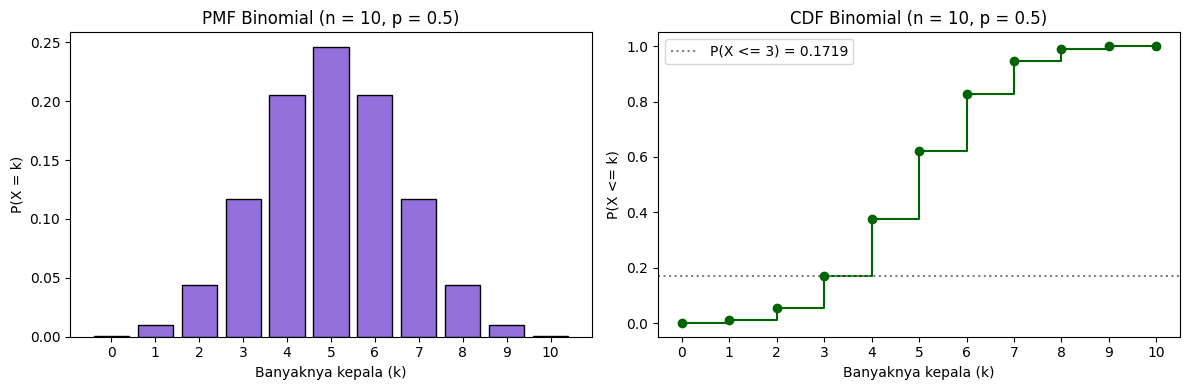

In [15]:
cdf_nilai = binom.cdf(k_nilai, n_lempar, p_kepala)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PMF: diagram batang
axes[0].bar(k_nilai, pmf_nilai, color="mediumpurple", edgecolor="black")
axes[0].set_title("PMF Binomial (n = 10, p = 0.5)")
axes[0].set_xlabel("Banyaknya kepala (k)")
axes[0].set_ylabel("P(X = k)")
axes[0].set_xticks(k_nilai)

# CDF: grafik tangga
axes[1].step(k_nilai, cdf_nilai, where="post", color="darkgreen")
axes[1].scatter(k_nilai, cdf_nilai, color="darkgreen", zorder=3)
axes[1].axhline(p_maks_3, color="gray", linestyle=":",
                label=f"P(X <= 3) = {p_maks_3:.4f}")
axes[1].set_title("CDF Binomial (n = 10, p = 0.5)")
axes[1].set_xlabel("Banyaknya kepala (k)")
axes[1].set_ylabel("P(X <= k)")
axes[1].set_xticks(k_nilai)
axes[1].legend()

plt.tight_layout()
plt.show()

**Hasil yang diharapkan.** **Gambar 11** memperlihatkan hasilnya. Grafik kiri berisi 11 batang
($k=0$ sampai $k=10$) yang simetris, dengan batang tertinggi di $k=5$ (sekitar 0.25) dan batang di $k=0$
serta $k=10$ hampir tidak terlihat. Grafik kanan berbentuk tangga naik dari mendekati 0 di $k=0$ sampai
tepat 1 di $k=10$, dengan garis bantu horizontal di sekitar 0.17.

**Interpretasi.** Pada grafik PMF, tinggi batang adalah probabilitas tepat $k$ kepala. Bentuknya simetris
karena $p=0{,}5$; bila $p$ lebih kecil, puncaknya bergeser ke kiri. Pada grafik CDF, tinggi titik di atas
suatu $k$ adalah probabilitas paling banyak $k$ kepala. CDF tidak pernah turun, dan tinggi setiap
lompatannya sama dengan tinggi batang PMF di titik yang sama, sehingga lompatan terbesar terjadi di $k=5$.

---
## C.4 Variabel acak kontinu

### C.4.1 Variabel acak kontinu dan distribusi normal

**Variabel acak kontinu** dapat bernilai berapa pun dalam suatu rentang, termasuk bilangan desimal yang
sangat rinci. Hasil pengukuran adalah contoh paling umum: tinggi badan bisa 165 cm, 165.3 cm, atau 165.27
cm, tergantung ketelitian alat ukur. Karena nilai yang mungkin tidak terhingga banyaknya, probabilitas
tidak lagi diberikan per nilai seperti PMF, melainkan melalui *probability density function* (PDF, fungsi
kepadatan probabilitas).

Distribusi kontinu yang paling terkenal adalah **distribusi normal**, berbentuk lonceng dan simetris
terhadap mean. Distribusi ini ditentukan oleh dua parameter: mean $\mu$ (letak pusat kurva) dan standar
deviasi $\sigma$ (lebar sebaran). PDF distribusi normal adalah:

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right) \qquad (13)$$

Rumus ini tidak perlu dihafal karena SciPy menghitungnya melalui `norm.pdf()`.

### C.4.2 PDF: kepadatan, bukan probabilitas

Tinggi kurva PDF adalah **kepadatan**, bukan probabilitas. Probabilitas pada variabel acak kontinu selalu
dihitung untuk sebuah interval, dan nilainya sama dengan **luas daerah di bawah kurva PDF** pada interval
tersebut. Luas total di bawah kurva sama dengan 1.

Konsekuensinya, probabilitas variabel acak kontinu bernilai tepat satu angka adalah nol, misalnya
$P(X = 165) = 0$, karena "interval" selebar nol memiliki luas nol. Dalam praktik, pertanyaan "tinggi tepat
165 cm" berarti "tinggi antara 164.5 dan 165.5 cm" (sesuai ketelitian alat ukur), dan interval tersebut
memiliki probabilitas positif. Akibat lainnya, pada distribusi kontinu $P(X < a)$ sama dengan $P(X \le a)$.

CDF untuk variabel acak kontinu didefinisikan sama seperti pada kasus diskrit: probabilitas variabel acak
bernilai kurang dari atau sama dengan suatu batas. Secara geometris, CDF adalah luas di bawah kurva PDF
dari ujung kiri sampai batas tersebut:

$$F(x) = P(X \le x) \qquad (14)$$

Dengan CDF, tiga jenis pertanyaan probabilitas dapat dijawab tanpa menghitung luas secara langsung.
Probabilitas di antara dua nilai dihitung dari selisih CDF:

$$P(a \le X \le b) = F(b) - F(a) \qquad (15)$$

Probabilitas lebih dari suatu nilai dihitung dari komplemennya:

$$P(X > a) = 1 - F(a) \qquad (16)$$

Di SciPy, $1 - F(a)$ juga tersedia langsung sebagai `norm.sf(a)` (*survival function*).

### C.4.3 Menghitung probabilitas normal dengan SciPy

**Contoh kasus.** Tinggi badan mahasiswa di suatu angkatan dimodelkan dengan distribusi normal dengan mean
165 cm dan standar deviasi 7 cm. Jika satu mahasiswa dipilih secara acak, berapa probabilitas tingginya:
(1) kurang dari 160 cm, (2) lebih dari 175 cm, (3) antara 160 dan 170 cm?

In [16]:
mu_tinggi = 165     # mean (cm)
sigma_tinggi = 7    # standar deviasi (cm)
model_tinggi = norm(loc=mu_tinggi, scale=sigma_tinggi)

# 1. Kurang dari 160 cm: F(160)
p_kurang_160 = model_tinggi.cdf(160)

# 2. Lebih dari 175 cm: 1 - F(175)
p_lebih_175 = 1 - model_tinggi.cdf(175)
p_lebih_175_sf = model_tinggi.sf(175)      # cara ringkas, hasil sama

# 3. Antara 160 dan 170 cm: F(170) - F(160)
p_160_170 = model_tinggi.cdf(170) - model_tinggi.cdf(160)

print(f"P(X < 160)        = {p_kurang_160:.4f}")
print(f"P(X > 175)        = {p_lebih_175:.4f}  (dengan sf: {p_lebih_175_sf:.4f})")
print(f"P(160 < X < 170)  = {p_160_170:.4f}")

# Tinggi kurva di puncak: kepadatan, bukan probabilitas
print(f"f(165)            = {model_tinggi.pdf(165):.4f}")

P(X < 160)        = 0.2375
P(X > 175)        = 0.0766  (dengan sf: 0.0766)
P(160 < X < 170)  = 0.5249
f(165)            = 0.0570


**Hasil yang diharapkan.**

```text
P(X < 160)        = 0.2375
P(X > 175)        = 0.0766  (dengan sf: 0.0766)
P(160 < X < 170)  = 0.5249
f(165)            = 0.0570
```

**Interpretasi.** Menurut model, sekitar 23.75% mahasiswa memiliki tinggi di bawah 160 cm, sekitar 7.66%
di atas 175 cm, dan sekitar 52.49% di antara 160 dan 170 cm. Nilai $f(165) \approx 0{,}0570$ bukan berarti
5.7% mahasiswa bertinggi tepat 165 cm, melainkan kepadatan di puncak kurva dengan satuan "per cm". Bila
dikalikan lebar interval 1 cm, hasilnya mendekati probabilitas tinggi antara 164.5 dan 165.5 cm.

### C.4.4 Visualisasi kurva normal dan area probabilitas

**Contoh kasus.** Gambarkan ketiga probabilitas pada C.4.3 sebagai daerah arsiran di bawah kurva PDF, lalu
gambarkan kurva CDF-nya.

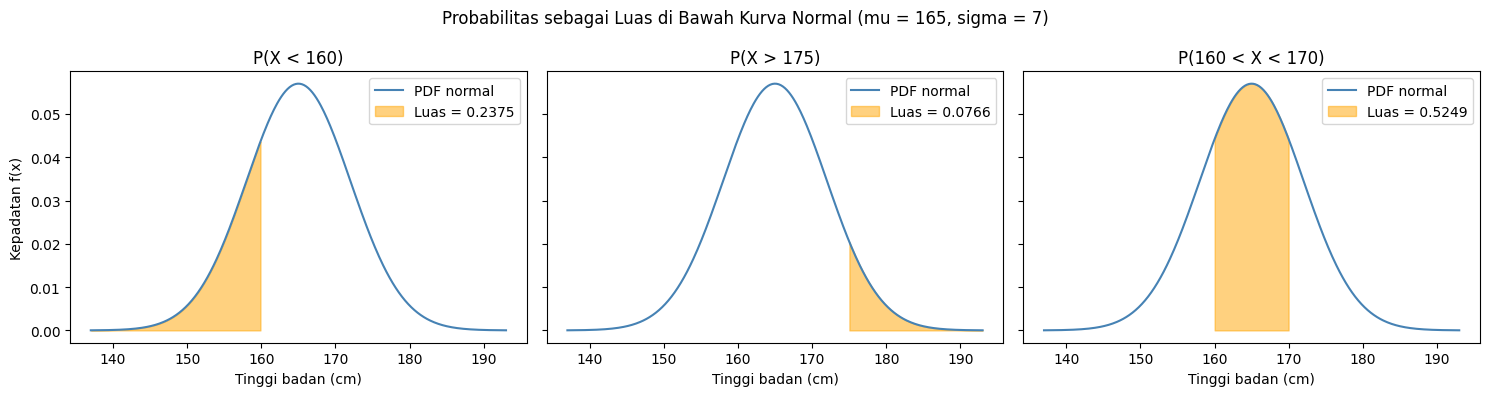

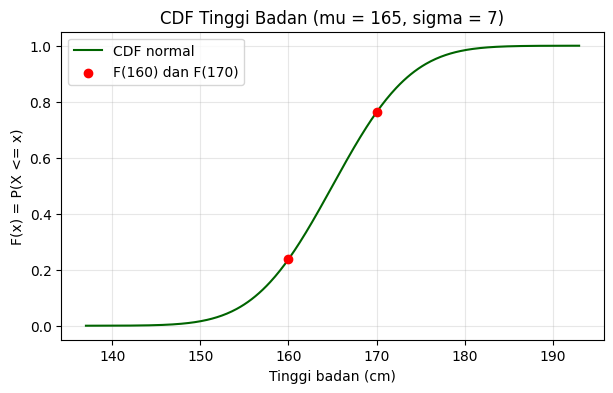

In [17]:
x = np.linspace(mu_tinggi - 4 * sigma_tinggi, mu_tinggi + 4 * sigma_tinggi, 400)
pdf_x = model_tinggi.pdf(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
pertanyaan = [
    ("P(X < 160)", x <= 160, p_kurang_160),
    ("P(X > 175)", x >= 175, p_lebih_175),
    ("P(160 < X < 170)", (x >= 160) & (x <= 170), p_160_170),
]

for ax, (judul, daerah, peluang) in zip(axes, pertanyaan):
    ax.plot(x, pdf_x, color="steelblue", label="PDF normal")
    ax.fill_between(x, pdf_x, where=daerah, color="orange", alpha=0.5,
                    label=f"Luas = {peluang:.4f}")
    ax.set_title(judul)
    ax.set_xlabel("Tinggi badan (cm)")
    ax.legend()
axes[0].set_ylabel("Kepadatan f(x)")

plt.suptitle("Probabilitas sebagai Luas di Bawah Kurva Normal (mu = 165, sigma = 7)")
plt.tight_layout()
plt.show()

# Kurva CDF
plt.figure(figsize=(7, 4))
plt.plot(x, model_tinggi.cdf(x), color="darkgreen", label="CDF normal")
plt.scatter([160, 170], model_tinggi.cdf([160, 170]), color="red", zorder=3,
            label="F(160) dan F(170)")
plt.title("CDF Tinggi Badan (mu = 165, sigma = 7)")
plt.xlabel("Tinggi badan (cm)")
plt.ylabel("F(x) = P(X <= x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Hasil yang diharapkan.** **Gambar 12** berisi tiga panel kurva lonceng yang identik, berpuncak di 165 cm.
Panel kiri mengarsir ekor kiri sampai 160 cm, panel tengah mengarsir ekor kanan mulai 175 cm (daerah tipis),
dan panel kanan mengarsir bagian tengah dari 160 sampai 170 cm. Legenda setiap panel menyebutkan luas
arsiran. **Gambar 13** berupa kurva huruf S yang naik dari 0 ke 1, dengan dua titik merah pada 160 cm
(sekitar 0.24) dan 170 cm (sekitar 0.76).

**Interpretasi.** Pada grafik PDF, probabilitas dibaca dari **luas arsiran**, bukan dari tinggi kurva.
Daerah tengah memiliki luas terbesar karena berada di sekitar puncak. Pada grafik CDF, tinggi kurva langsung
menyatakan probabilitas kumulatif: selisih tinggi dua titik merah (sekitar 0.76 dikurangi 0.24) sama dengan
luas arsiran panel kanan (0.5249), sesuai rumus (15).

---
## C.5 Studi kasus terpadu: nilai ujian akhir satu angkatan

Studi kasus ini menggabungkan seluruh langkah: membuat data, menghitung statistik, membuat visualisasi,
memodelkan dengan distribusi normal, dan menafsirkan hasil. Perhatikan perbedaan dua jenis angka yang akan
muncul:

- **Statistik dari data pengamatan** menggambarkan apa yang benar-benar terjadi pada 60 mahasiswa tersebut.
- **Probabilitas dari model distribusi** menggambarkan apa yang diperkirakan bila data dianggap mengikuti
  distribusi normal. Angka ini hanya sebaik asumsi modelnya.

**Contoh kasus.** Nilai ujian akhir 60 mahasiswa disimulasikan. Batas lulus adalah 60 dan batas nilai A
adalah 85. Pertanyaan yang ingin dijawab:

1. Bagaimana pusat dan sebaran nilai angkatan ini?
2. Berapa proporsi mahasiswa yang lulus dan yang mendapat A?
3. Apakah model normal cocok untuk menggambarkan data ini, dan apa keterbatasannya?

**Langkah 1: membuat data.** Data dibangkitkan dari distribusi normal dengan mean 80 dan standar deviasi 12,
lalu dibulatkan dan dibatasi agar berada dalam rentang 0 sampai 100, seperti nilai ujian sebenarnya.

In [18]:
rng = np.random.default_rng(42)

nilai_akhir = rng.normal(loc=80, scale=12, size=60)      # data mentah desimal
nilai_akhir = np.clip(np.round(nilai_akhir), 0, 100)     # bulatkan, batasi 0-100
df_akhir = pd.DataFrame({"nilai": nilai_akhir.astype(int)})

print(df_akhir.head())
print("Banyaknya data:", len(df_akhir))

   nilai
0     84
1     68
2     89
3     91
4     57
Banyaknya data: 60


**Hasil yang diharapkan** (ilustrasi dengan seed 42):

```text
   nilai
0     84
1     68
2     89
3     91
4     57
Banyaknya data: 60
```

**Langkah 2: statistik deskriptif.**

In [19]:
nilai = df_akhir["nilai"]

rata = nilai.mean()
std = nilai.std()          # pandas: standar deviasi sampel (ddof=1)
q1_akhir, q3_akhir = nilai.quantile([0.25, 0.75])

print(f"Mean     : {rata:.2f}")
print(f"Median   : {nilai.median():.2f}")
print(f"Std      : {std:.2f}")
print(f"Min, Max : {nilai.min()}, {nilai.max()}")
print(f"Q1, Q3   : {q1_akhir:.2f}, {q3_akhir:.2f}  (IQR = {q3_akhir - q1_akhir:.2f})")

# Proporsi dari data pengamatan
prop_lulus = (nilai >= 60).mean()
prop_a = (nilai >= 85).mean()
print(f"Proporsi lulus (>= 60) : {prop_lulus:.4f}")
print(f"Proporsi nilai A (>= 85): {prop_a:.4f}")

Mean     : 80.75
Median   : 81.50
Std      : 9.21
Min, Max : 57, 100
Q1, Q3   : 74.00, 88.00  (IQR = 14.00)
Proporsi lulus (>= 60) : 0.9833
Proporsi nilai A (>= 85): 0.3667


**Hasil yang diharapkan** (ilustrasi dengan seed 42):

```text
Mean     : 80.75
Median   : 81.50
Std      : 9.21
Min, Max : 57, 100
Q1, Q3   : 74.00, 88.00  (IQR = 14.00)
Proporsi lulus (>= 60) : 0.9833
Proporsi nilai A (>= 85): 0.3667
```

**Langkah 3: visualisasi dan pencocokan model normal.** Histogram digambar dengan `density=True`, sehingga
tinggi batang berupa kepadatan (luas total batang sama dengan 1) dan dapat dibandingkan langsung dengan
kurva PDF normal. Parameter model diambil dari mean dan standar deviasi sampel.

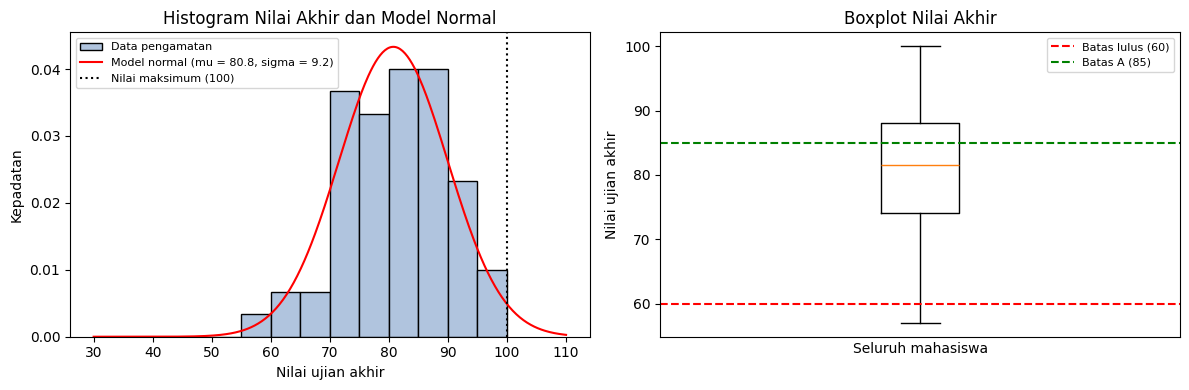

In [20]:
model_nilai = norm(loc=rata, scale=std)
x_nilai = np.linspace(30, 110, 400)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(nilai, bins=range(40, 105, 5), density=True,
             color="lightsteelblue", edgecolor="black", label="Data pengamatan")
axes[0].plot(x_nilai, model_nilai.pdf(x_nilai), color="red",
             label=f"Model normal (mu = {rata:.1f}, sigma = {std:.1f})")
axes[0].axvline(100, color="black", linestyle=":", label="Nilai maksimum (100)")
axes[0].set_title("Histogram Nilai Akhir dan Model Normal")
axes[0].set_xlabel("Nilai ujian akhir")
axes[0].set_ylabel("Kepadatan")
axes[0].legend(fontsize=8)

axes[1].boxplot(nilai)
axes[1].axhline(60, color="red", linestyle="--", label="Batas lulus (60)")
axes[1].axhline(85, color="green", linestyle="--", label="Batas A (85)")
axes[1].set_title("Boxplot Nilai Akhir")
axes[1].set_xlabel("Seluruh mahasiswa")
axes[1].set_ylabel("Nilai ujian akhir")
axes[1].set_xticks([])
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Hasil yang diharapkan** (ilustrasi dengan seed 42). **Gambar 14** memperlihatkan hasilnya. Grafik kiri
berupa histogram dengan batang tertinggi pada interval 70 sampai 90 dan beberapa batang pendek di bawah 70,
ditimpa kurva lonceng merah yang berpuncak di sekitar 81. Ekor kanan kurva merah melewati garis titik-titik
di nilai 100. Grafik kanan berupa boxplot tegak dengan kotak dari 74 sampai 88, garis putus-putus merah di
60, garis putus-putus hijau di 85, whisker dari 57 sampai 100, dan tanpa titik pencilan.

**Langkah 4: membandingkan data dengan model.**

In [21]:
# Probabilitas menurut model normal
p_lulus_model = 1 - model_nilai.cdf(59.5)   # nilai bulat >= 60
p_a_model = 1 - model_nilai.cdf(84.5)       # nilai bulat >= 85
p_lebih_100 = 1 - model_nilai.cdf(100)      # nilai mustahil

ringkasan = pd.DataFrame({
    "Kejadian": ["Lulus (>= 60)", "Nilai A (>= 85)", "Nilai > 100"],
    "Proporsi data": [prop_lulus, prop_a, (nilai > 100).mean()],
    "Probabilitas model": [p_lulus_model, p_a_model, p_lebih_100],
})
print(ringkasan.round(4).to_string(index=False))

       Kejadian  Proporsi data  Probabilitas model
  Lulus (>= 60)         0.9833              0.9895
Nilai A (>= 85)         0.3667              0.3419
    Nilai > 100         0.0000              0.0183


Batas 59.5 dan 84.5 dipakai karena nilai ujian berupa bilangan bulat, sedangkan model normal bersifat
kontinu. Nilai bulat 60 mewakili interval 59.5 sampai 60.5 pada skala kontinu, sehingga "nilai minimal 60"
diterjemahkan menjadi $X \ge 59{,}5$. Penyesuaian ini disebut **koreksi kontinuitas**.

**Hasil yang diharapkan** (ilustrasi dengan seed 42):

```text
       Kejadian  Proporsi data  Probabilitas model
  Lulus (>= 60)         0.9833              0.9895
Nilai A (>= 85)         0.3667              0.3419
    Nilai > 100         0.0000              0.0183
```

**Interpretasi.** Statistik dari data pengamatan menunjukkan rata-rata angkatan 80.75 dan median 81.50,
dengan standar deviasi 9.21. Median yang sedikit lebih tinggi daripada mean menandakan sebaran agak miring
ke kiri: sebagian kecil mahasiswa bernilai cukup rendah dan menarik rata-rata turun, sesuai whisker bawah
pada boxplot yang lebih panjang (57 sampai 74) daripada whisker atas (88 sampai 100). Sebanyak 98.33%
mahasiswa lulus (59 dari 60), dan 36.67% mendapat A (22 dari 60).

Model normal memberi taksiran yang cukup dekat untuk proporsi lulus (98.95%) dan nilai A (34.19%), sehingga
untuk data ini model berguna sebagai gambaran kasar. Namun, model juga memberi probabilitas 1.83% untuk nilai
di atas 100, yaitu sekitar satu dari 60 mahasiswa, padahal nilai seperti itu mustahil. Ekor kurva merah yang
melewati garis 100 pada histogram adalah wujud visual masalah ini.

Model normal untuk nilai ujian merupakan pendekatan, dan keterbatasannya perlu disadari:

- Nilai ujian dibatasi antara 0 dan 100, sedangkan distribusi normal tidak memiliki batas. Model selalu
  memberi probabilitas positif untuk nilai mustahil, terutama bila mean mendekati 100.
- Nilai ujian bersifat diskrit (bilangan bulat), sedangkan model normal kontinu, sehingga diperlukan koreksi
  kontinuitas.
- Bentuk sebaran nyata bisa tidak simetris, misalnya bila ujian terlalu mudah sehingga banyak mahasiswa
  mengumpul di nilai tinggi.

Model tetap berguna untuk menaksir secara cepat dan membandingkan antarkelas, selama hasilnya diperiksa
terhadap data pengamatan seperti pada hasil Langkah 4.